# Task 3: Forecast Future Market Trends
Uses the best-performing model from Task 2 (ARIMA or LSTM) to forecast 12 months ahead with confidence intervals.

In [2]:
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from tensorflow.keras.models import load_model
from statsmodels.tsa.arima.model import ARIMA

from data_loader import load_local_data

In [3]:
TICKERS = ['TSLA', 'BND', 'SPY']
data = load_local_data(TICKERS, save_dir='../data/processed')

tsla = data['TSLA']
close_prices = tsla['Close']

train = close_prices[:'2024-12-31']
test = close_prices['2025-01-01':]
full_series = pd.concat([train, test])

print(f"Full series: {full_series.index.min()} to {full_series.index.max()} ({len(full_series)} rows)")

Full series: 2015-01-02 00:00:00 to 2026-06-29 00:00:00 (2888 rows)


In [4]:
# Set this based on your comparison_df results from Task 2 (lower RMSE/MAPE wins)
MODEL_CHOICE = 'ARIMA'  # or 'LSTM'

FORECAST_MONTHS = 12
FORECAST_DAYS = FORECAST_MONTHS * 21  # ~21 trading days/month

future_dates = pd.bdate_range(start=full_series.index[-1] + pd.Timedelta(days=1), periods=FORECAST_DAYS)

In [5]:
best_order = (1, 1, 1)  # replace with your actual best_order from Task 2's auto_arima result

final_arima = ARIMA(full_series, order=best_order).fit()

future_result = final_arima.get_forecast(steps=FORECAST_DAYS)
future_forecast = pd.Series(future_result.predicted_mean.values, index=future_dates)
future_ci = future_result.conf_int(alpha=0.05)
future_ci.index = future_dates

ci_lower = future_ci.iloc[:, 0]
ci_upper = future_ci.iloc[:, 1]

c:\Users\HP EliteBook\Desktop\my-projects\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\HP EliteBook\Desktop\my-projects\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\HP EliteBook\Desktop\my-projects\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\HP EliteBook\Desktop\my-projects\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\ba

In [6]:
lstm_model = load_model('../data/processed/lstm_tsla_model.keras')
scaler = joblib.load('../data/processed/lstm_scaler.pkl')

WINDOW = 60
full_scaled = scaler.transform(full_series.values.reshape(-1, 1))
last_window = full_scaled[-WINDOW:].reshape(1, WINDOW, 1)

# --- Point forecast (fast: direct call, not .predict()) ---
future_preds_scaled = []
window = last_window.copy()
for _ in range(FORECAST_DAYS):
    next_pred = lstm_model(window, training=False).numpy()
    future_preds_scaled.append(next_pred[0, 0])
    window = np.append(window[:, 1:, :], [[next_pred[0]]], axis=1)

future_forecast_vals = scaler.inverse_transform(np.array(future_preds_scaled).reshape(-1, 1)).flatten()
future_forecast = pd.Series(future_forecast_vals, index=future_dates)

# --- Confidence interval via batched MC Dropout ---
N_SIMS = 50

def mc_dropout_forecast_batched(model, last_window, n_days, n_sims=50):
    # Repeat the starting window n_sims times -> shape (n_sims, WINDOW, 1)
    window_batch = np.repeat(last_window, n_sims, axis=0)
    sims = np.zeros((n_sims, n_days))

    for d in range(n_days):
        preds = model(window_batch, training=True).numpy()  # shape (n_sims, 1), dropout active
        sims[:, d] = preds[:, 0]
        # slide window for each simulation in the batch
        window_batch = np.concatenate([window_batch[:, 1:, :], preds.reshape(n_sims, 1, 1)], axis=1)

    return sims

sims_scaled = mc_dropout_forecast_batched(lstm_model, last_window, FORECAST_DAYS, n_sims=N_SIMS)
sims = scaler.inverse_transform(sims_scaled.reshape(-1, 1)).reshape(sims_scaled.shape)

ci_lower = pd.Series(np.percentile(sims, 2.5, axis=0), index=future_dates)
ci_upper = pd.Series(np.percentile(sims, 97.5, axis=0), index=future_dates)

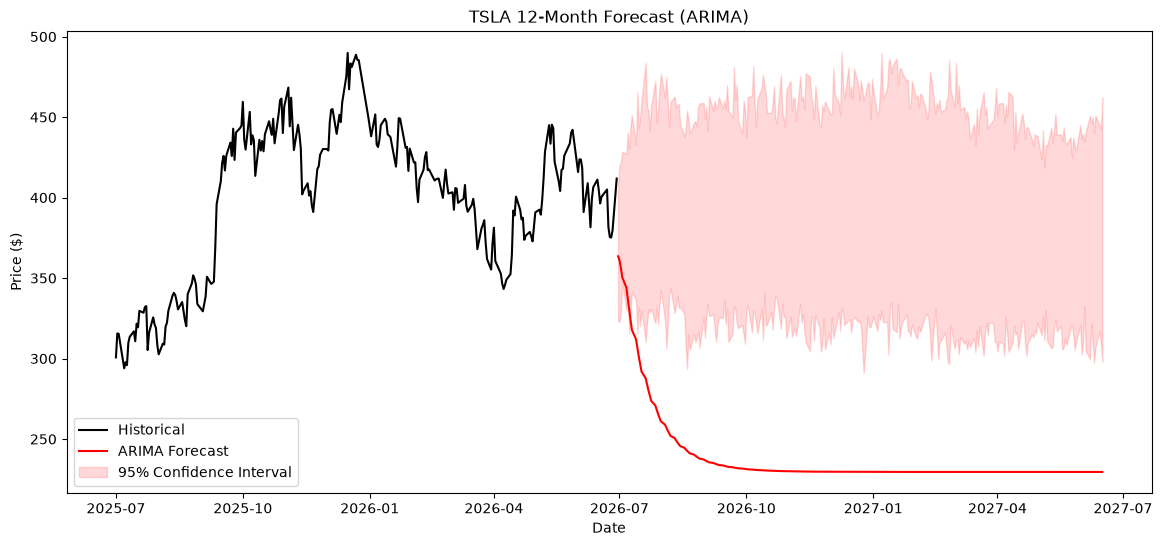

In [7]:
plt.figure(figsize=(14, 6))
plt.plot(full_series.index[-250:], full_series[-250:], label='Historical', color='black')
plt.plot(future_forecast.index, future_forecast, label=f'{MODEL_CHOICE} Forecast', color='red')
plt.fill_between(future_dates, ci_lower, ci_upper, color='red', alpha=0.15, label='95% Confidence Interval')
plt.title(f'TSLA {FORECAST_MONTHS}-Month Forecast ({MODEL_CHOICE})')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.show()

In [8]:
ci_width = ci_upper - ci_lower

start_width = round(ci_width.iloc[0], 2)
end_width = round(ci_width.iloc[-1], 2)
widening_factor = round(end_width / start_width, 2)

print(f"CI width at start of horizon: {start_width}")
print(f"CI width at end of horizon: {end_width}")
print(f"Widening factor: {widening_factor}x")

CI width at start of horizon: 83.89
CI width at end of horizon: 163.9
Widening factor: 1.95x


In [9]:
pct_change = (future_forecast.iloc[-1] - full_series.iloc[-1]) / full_series.iloc[-1] * 100
annualized_forecast_return = (1 + pct_change / 100) ** (12 / FORECAST_MONTHS) - 1

print(f"Projected {FORECAST_MONTHS}-month change: {pct_change:.2f}%")
print(f"Annualized forecast return: {annualized_forecast_return*100:.2f}%")

Projected 12-month change: -44.26%
Annualized forecast return: -44.26%


In [10]:
import json

forecast_summary = {
    'model_choice': MODEL_CHOICE,
    'annualized_forecast_return': annualized_forecast_return,
    'pct_change_12m': pct_change,
    'ci_widening_factor': widening_factor
}

with open('../data/processed/forecast_summary.json', 'w') as f:
    json.dump(forecast_summary, f)

print("Forecast summary saved for Task 4.")

Forecast summary saved for Task 4.


### Trend Analysis

The ARIMA forecast projects a sharp decline in TSLA's price over the next 12 months, falling from
approximately $365 at the start of the forecast horizon to a flattened level around $230 by month
3-4, then remaining essentially constant through month 12. This produces a projected 12-month change
of **-44.26%** (annualized return: -44.26%, since the horizon is exactly 12 months).

This flattening pattern is a known characteristic of ARIMA models at longer horizons: once the
autoregressive and moving-average components decay, the point forecast converges toward the series'
long-run unconditional mean rather than capturing any genuine forward-looking trend. In other words,
the sharp initial drop reflects real short-term momentum in the model, but the flat plateau afterward
is more a mathematical artifact of ARIMA's mean-reverting structure than a credible market prediction
of TSLA cratering and then stabilizing at $230. This is an important limitation to flag: the model
has "run out of information" past a few months and is defaulting to its statistical center of gravity.

Regarding uncertainty: the 95% confidence interval widens from a width of **83.89** at the start of the
forecast to **163.9** by month 12 — a **1.95x widening factor**. This is a real but relatively modest
widening compared to the scale of the point-forecast decline itself; notably, the CI band is wide enough
that it still contains the current price level (~$365-400) throughout most of the horizon, meaning the
model is not confidently ruling out TSLA holding steady or even continuing near current levels. Given
that the point forecast's drop is likely an artifact of mean-reversion rather than genuine predictive
signal, the width and persistence of this interval should be read as an honest admission that ARIMA's
long-horizon price predictions carry very low confidence — consistent with the Efficient Market
Hypothesis's expectation that precise multi-month price prediction is generally not achievable from
historical price data alone.

### Opportunities & Risks

- **Opportunity:** None clearly indicated by the point forecast — the model shows no projected price
  appreciation over the 12-month horizon.
- **Risk:** The point forecast implies a -44.26% decline, but this should be treated with caution given
  ARIMA's tendency to flatten toward the historical mean at long horizons rather than track a genuine
  trend.
- **Risk:** The 95% CI at month 12 spans roughly $150-$460 (based on the ~$230 midpoint ± half of the
  163.9 width), an extremely wide range that signals very low forecast reliability at that horizon.
- **Key takeaway:** This forecast should be treated as one weak input among many for portfolio decisions
  (per the Efficient Market Hypothesis), not a standalone basis for allocation — which is exactly why
  Task 4 combines it with historical returns for BND/SPY rather than relying on it in isolation.